In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import plotnine as p9

plt.rcParams["figure.figsize"] = (15,7)

/opt/conda/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.9.1-CAPI-1.14.2) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.


## ***Read & View Data***

In [2]:
X_train = pd.read_csv("../input/titanic/train.csv")
X_test = pd.read_csv("../input/titanic/test.csv")

In [3]:
display(X_train)
display(X_test)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4]:
# Remove PassengerId and Name as they are uninformative
X_train.drop(["PassengerId", 'Name'], axis = 1, inplace = True)
X_test.drop(["PassengerId","Name"], axis = 1, inplace = True)

In [5]:
# Checking for any duplicated values
print(X_train.duplicated().sum())
print(X_test.duplicated().sum())

15
1


In [6]:
# Drop Duplicates
X_train.drop_duplicates(inplace = True)
X_test.drop_duplicates(inplace = True)

In [7]:
# View null counts
print(X_train.isnull().sum(), '\n')
print(X_test.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age         165
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       673
Embarked      2
dtype: int64 

Pclass        0
Sex           0
Age          85
SibSp         0
Parch         0
Ticket        0
Fare          1
Cabin       326
Embarked      0
dtype: int64


## ***Visualizing Missing Values***

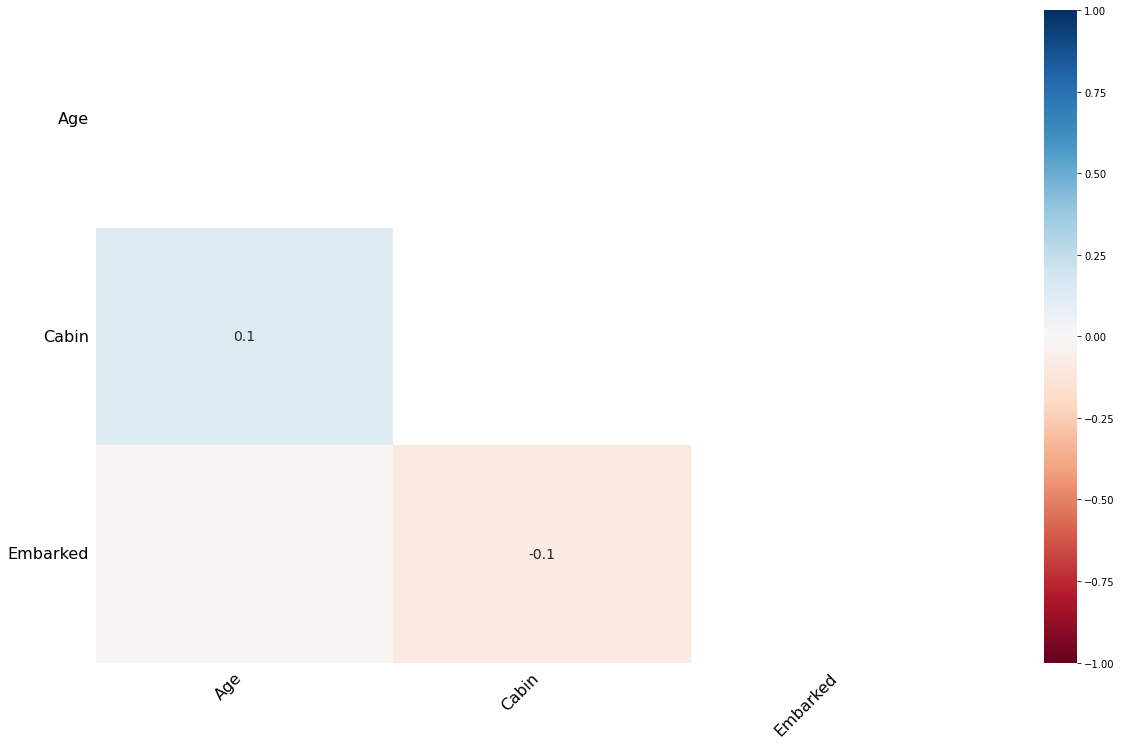

In [8]:
msno.heatmap(X_train);

<AxesSubplot:>

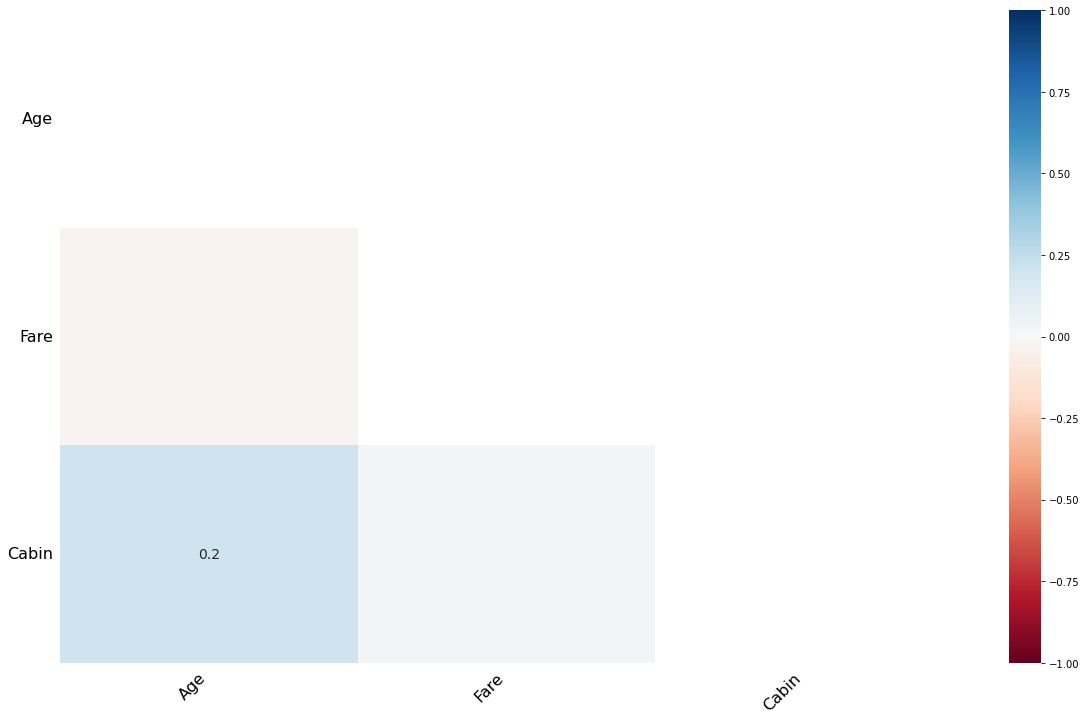

In [9]:
msno.heatmap(X_test)

## ***Data Cleaning***

In [10]:
# Drop cabin column as it has too many null values
X_train.drop("Cabin", axis =1, inplace = True)
X_test.drop("Cabin", axis =1, inplace = True)

In [11]:
# Fill age column with mean
X_train['Age'].fillna(X_train['Age'].mean(), inplace=True)
X_test['Age'].fillna(X_test['Age'].mean(), inplace=True)

In [12]:
# Check for remaining nulls
X_train.isnull().sum()
X_test.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        1
Embarked    0
dtype: int64

In [13]:
# One row is not that significant so I dropped it
X_train.dropna(inplace = True)
X_test.dropna(inplace = True)

In [14]:
# No nulls remain
X_train.isnull().sum()
X_test.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

## ***Univariate Data Analysis***

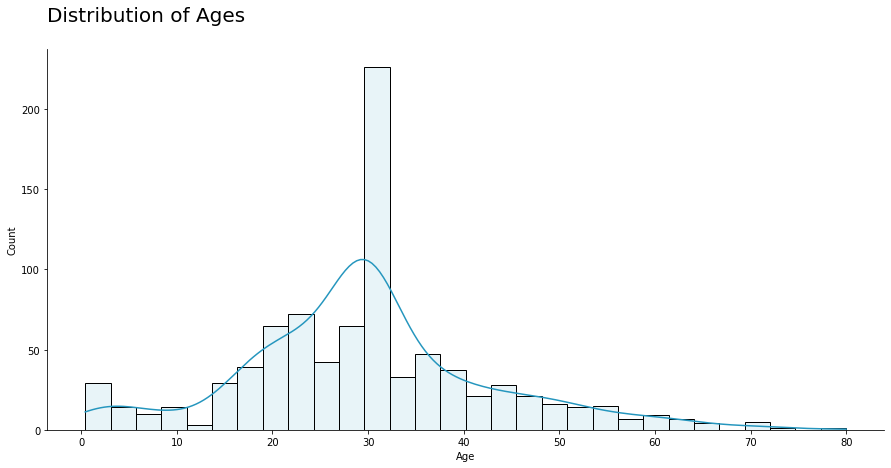

In [15]:
sns.histplot(X_train['Age'], color = '#2596be', kde = True, alpha = 0.1);
plt.title("Distribution of Ages\n", size =20, loc = 'left')
sns.despine()

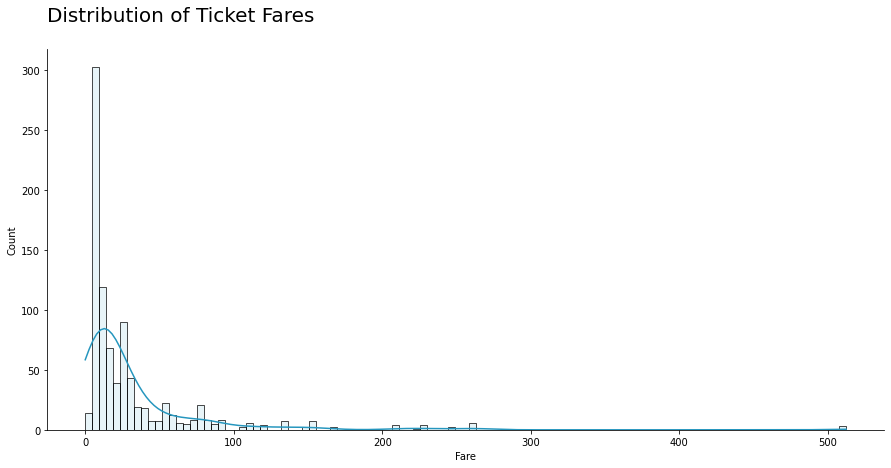

In [16]:
sns.histplot(X_train['Fare'], color = '#2596be', kde = True, alpha = 0.1);
plt.title("Distribution of Ticket Fares\n", size =20, loc = 'left')
sns.despine()

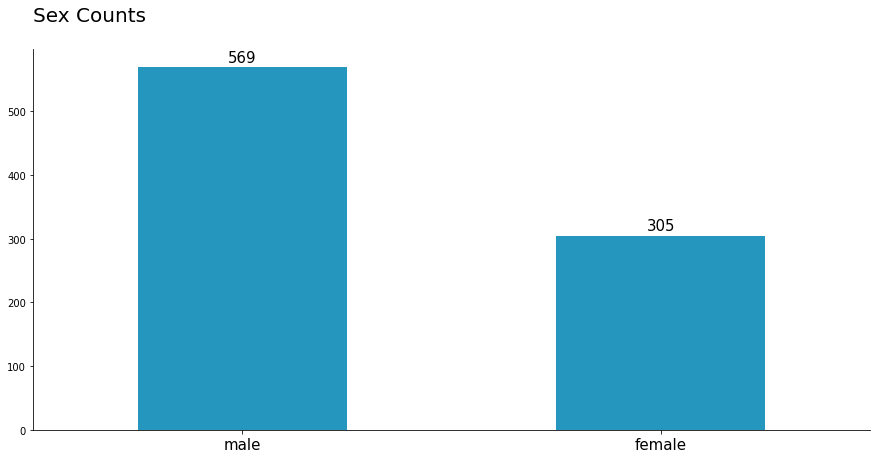

In [17]:
plt.title("Sex Counts\n", size =20, loc = 'left')
sns.despine()
ax = X_train.Sex.value_counts().plot(kind = 'bar', color = '#2596be');
plt.xticks(rotation=0, size = 15)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2, p.get_height()), 
       ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', size = 15)

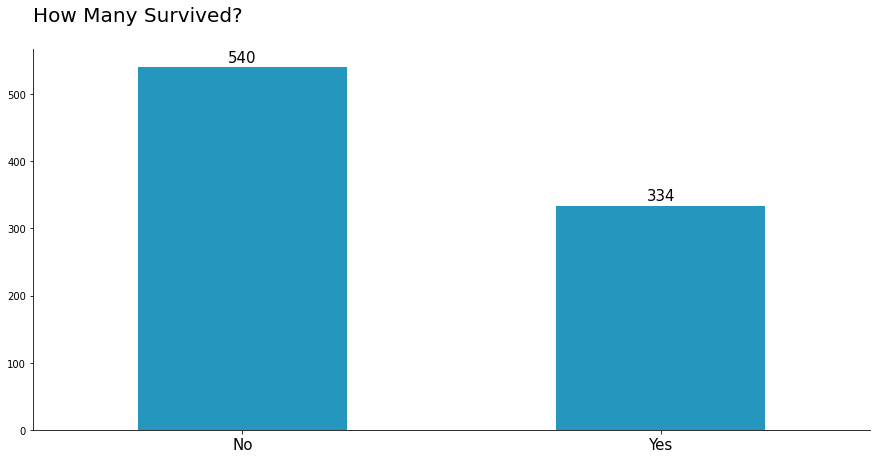

In [18]:
X_train['Survived'].replace({0: 'No', 1:'Yes'}, inplace = True)
ax = X_train.Survived.value_counts().plot(kind = 'bar', color = '#2596be');

plt.title("How Many Survived?\n", size =20, loc = 'left')
sns.despine()
plt.xticks(rotation=0, size = 15)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2, p.get_height()), 
       ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', size = 15)

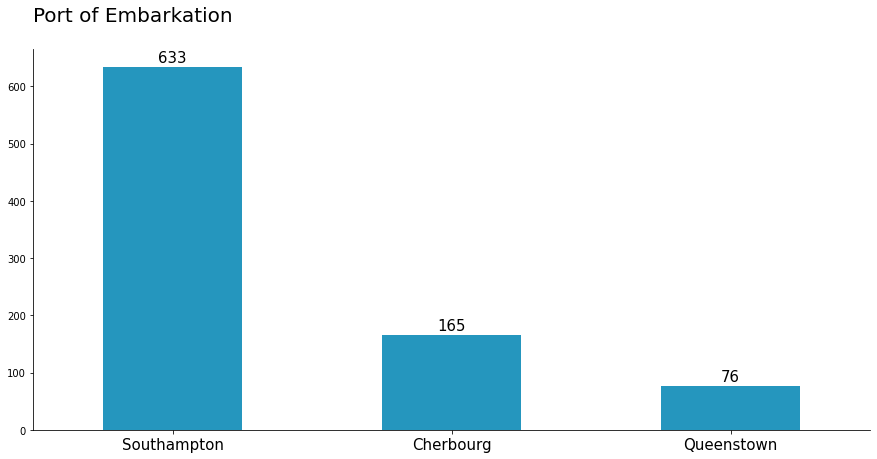

In [19]:
X_train.replace({'C': 'Cherbourg', 'Q':'Queenstown', 'S': 'Southampton'}, inplace = True)

ax = X_train.Embarked.value_counts().plot(kind = 'bar', color = '#2596be');

plt.title("Port of Embarkation\n", size =20, loc = 'left')
sns.despine()
plt.xticks(rotation=0, size = 15)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2, p.get_height()), 
       ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', size = 15)

## ***Bivariate Data Analysis***

***Did Age Affect Someone's Chance of Survival?***

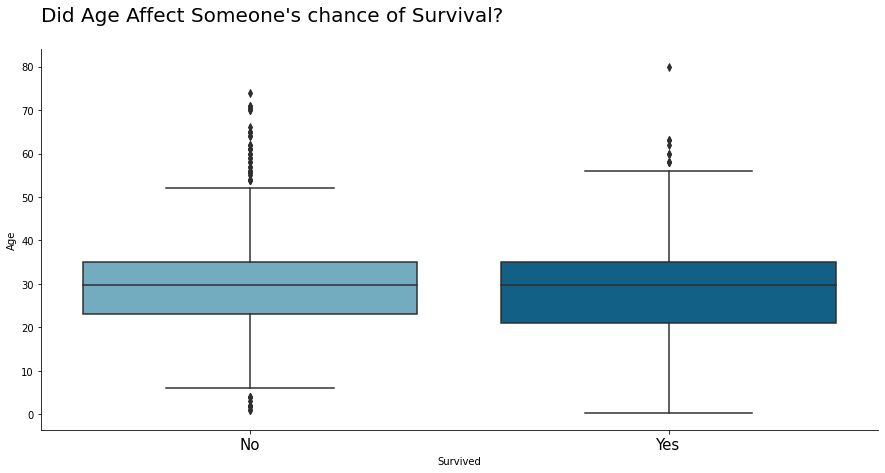

In [20]:
plt.title("Did Age Affect Someone's chance of Survival?\n", size =20, loc = 'left')
sns.despine()
plt.xticks(rotation=0, size = 15)
mypal = sns.color_palette("ocean", 0) + sns.color_palette("ocean_r", 4)
sns.boxplot(x = 'Survived', y = 'Age', data = X_train, palette = mypal); 

From the graph above, it's apparent that:

* The median age for survivors and non survivors, were almost the same.

So I don't think age attributed to someone's chance of survival.

***Did Sex Affect the Chance of Survival?***

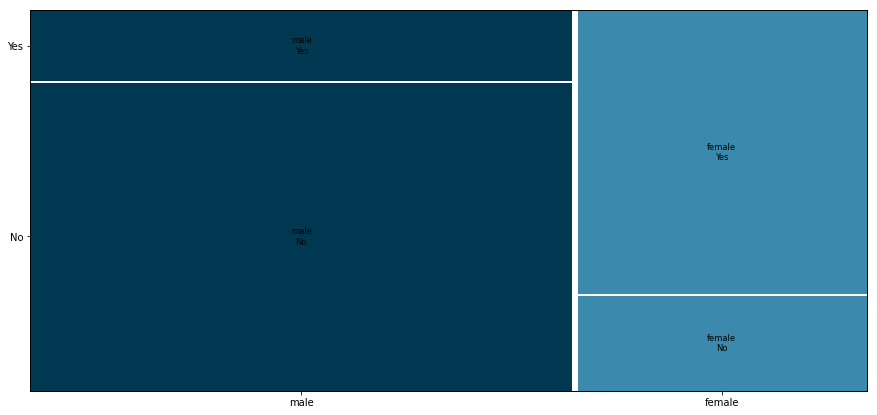

In [21]:
from statsmodels.graphics.mosaicplot import mosaic

props={}
props[('female','Yes')]={'facecolor':'#3b89ac', 'edgecolor':'white'}
props[('female','No')]={'facecolor':'#3b89ac', 'edgecolor':'white'}
props[('male','Yes')]={'facecolor':'#003851','edgecolor':'white'}
props[('male','No')]= {'facecolor':'#003851','edgecolor':'white'}

ax = mosaic(data=X_train, index=['Sex', 'Survived'], properties = props);

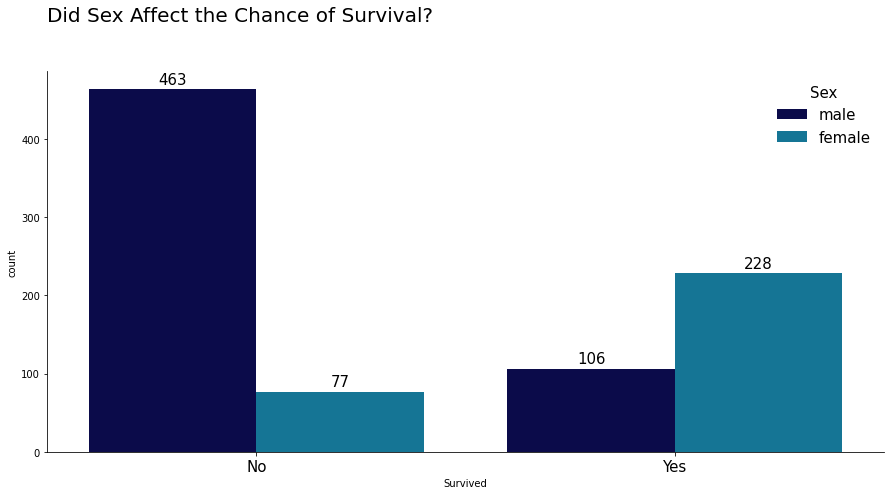

In [22]:
plt.title("Did Sex Affect the Chance of Survival?\n\n", size =20, loc = 'left')
sns.despine()
plt.xticks(rotation=0, size = 15)

ax = sns.countplot(x ='Survived', data = X_train, hue = 'Sex', palette = 'ocean')
plt.legend(title = 'Sex', frameon = False, fontsize = 15, title_fontsize =15)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2, p.get_height()), 
       ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', size = 15)

From the mosaic plot and the barplot above:

* From the survivors the majority were females.
* Around 74% of females survived compared to 18.6% of males.

***Did The Fare Paid Affect Who Survived?***

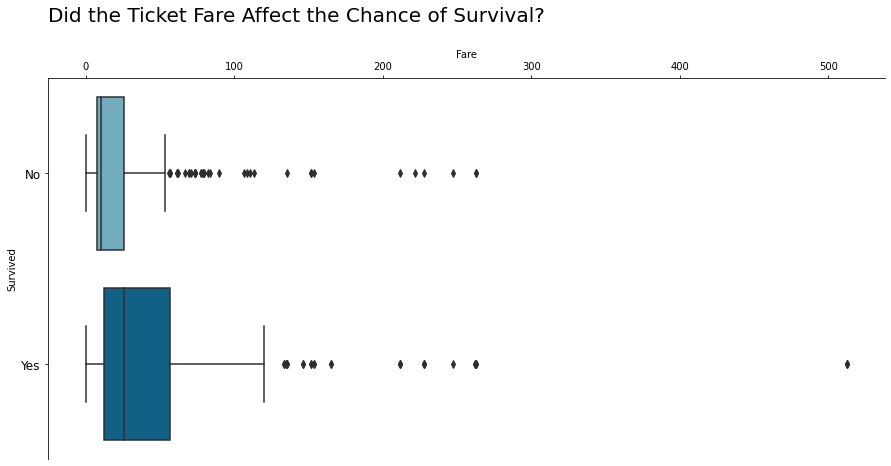

In [27]:
plt.title("Did the Ticket Fare Affect the Chance of Survival?\n", size =20, loc = 'left')
sns.despine(top = False, bottom = True)
plt.yticks(rotation=0, size = 12)
plot = sns.boxplot(y = 'Survived', x = 'Fare', data=X_train, palette = mypal, orient = 'h');
plot.xaxis.set_ticks_position("top")
plot.xaxis.set_label_position('top')

From the boxplot above:

* The median fare paid for survivors was higher than the fare paid by non survivors, this could mean that afluency attributed to survival.

***PClass & Survival***

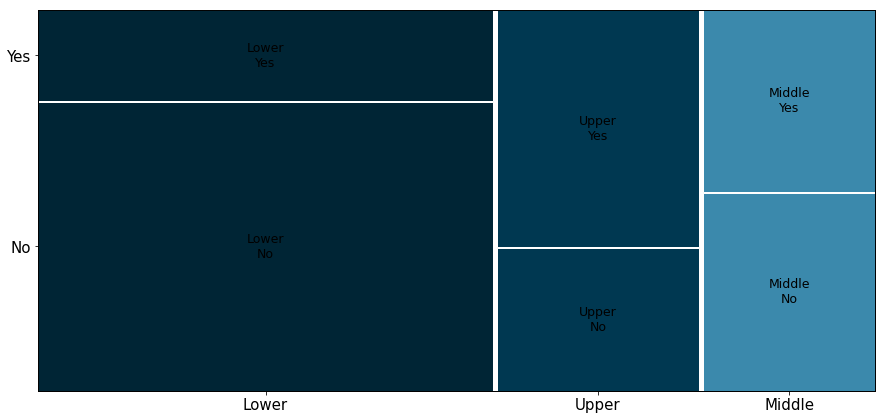

In [41]:
from statsmodels.graphics.mosaicplot import mosaic

props={}
props[('Middle','Yes')]={'facecolor':'#3b89ac', 'edgecolor':'white'}
props[('Middle','No')]={'facecolor':'#3b89ac', 'edgecolor':'white'}
props[('Upper','Yes')]={'facecolor':'#003851','edgecolor':'white'}
props[('Upper','No')]= {'facecolor':'#003851','edgecolor':'white'}
props[('Lower','Yes')]={'facecolor':'#002535','edgecolor':'white'}
props[('Lower','No')]= {'facecolor':'#002535','edgecolor':'white'}

mosaic(data=X_train, index=['Pclass', 'Survived'], properties = props);

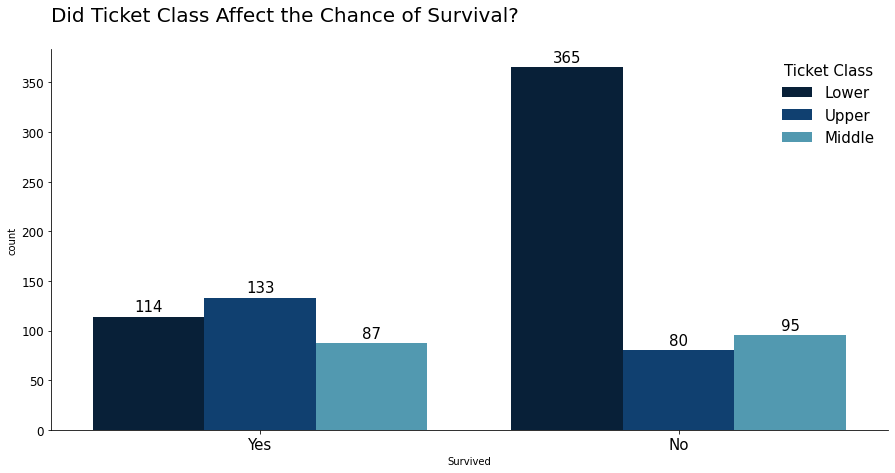

In [34]:
plt.title("Did Ticket Class Affect the Chance of Survival?\n", size =20, loc = 'left')
sns.despine()
plt.xticks(rotation=0, size = 15)
plt.yticks(rotation=0, size = 12)

X_train.Pclass = X_train.Pclass.replace({1:"Upper", 2:"Middle", 3:"Lower"})
order = pd.crosstab(X_train.Survived, X_train.Pclass).sort_values('Survived', ascending=False).index

ax = sns.countplot(x ='Survived', data = X_train, hue = 'Pclass', palette = 'ocean', order = order)

plt.legend(title = 'Ticket Class', frameon = False, fontsize = 15, title_fontsize =15)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2, p.get_height()), 
       ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', size = 15)

From the mosaic and barplot above:

* Passenger class seems to be correlated with survival, as the upper class had the highest survival rates, compares to lower and middle class.

***SibSp and Survival***

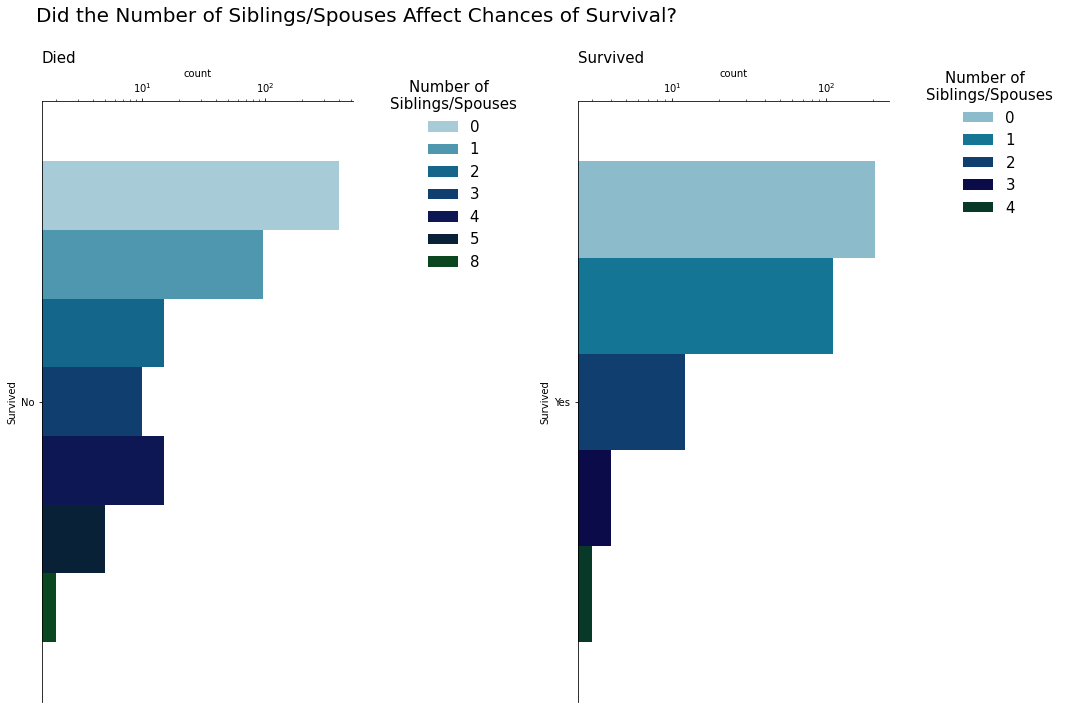

In [35]:
#Create subplots
fig, ax = plt.subplots(1,2, sharey=False)
fig.set_size_inches(15, 10)

# To order the bars
order1 = pd.crosstab(X_train.Survived[X_train.Survived == 'No'], X_train.SibSp).sort_values('Survived', ascending=False).index
order2 = pd.crosstab(X_train.Survived[X_train.Survived == 'Yes'], X_train.SibSp).sort_values('Survived', ascending=False).index

# Countplots
ax1 = sns.countplot(y ='Survived', orient = 'h', data = X_train[X_train.Survived == 'No'], hue = 'SibSp', palette = 'ocean_r', order = order1, ax = ax[0])
ax2 = sns.countplot(y ='Survived', orient = 'h', data = X_train[X_train.Survived == 'Yes'], hue = 'SibSp', palette = 'ocean_r', order = order2, ax = ax[1])

# Change scale to log scale
ax1.set(xscale="log");
ax2.set(xscale="log");

# Add legends
ax1.legend(title = '    Number of \nSiblings/Spouses', frameon = False, fontsize = 15, title_fontsize =15, loc=(1.1, 0.71))
ax2.legend(title = '    Number of \nSiblings/Spouses', frameon = False, fontsize = 15, title_fontsize =15, loc=(1.1, 0.8))

# Set suplots titles
ax[0].set_title("\nDied", loc = 'left', size = 15)
ax[1].set_title("\nSurvived", loc = 'left', size = 15)

# Add main title
fig.suptitle("Did the Number of Siblings/Spouses Affect Chances of Survival?", x = '0.333', size = 20)

# Remove border
sns.despine(top = False, bottom = True)

# Change axis ticks and label positions 
ax1.xaxis.set_ticks_position("top")
ax1.xaxis.set_label_position('top')

ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position('top')

fig.tight_layout()

From the barplot above:

* No one with 5 or 8 siblings survived.

***Parch & Survival***

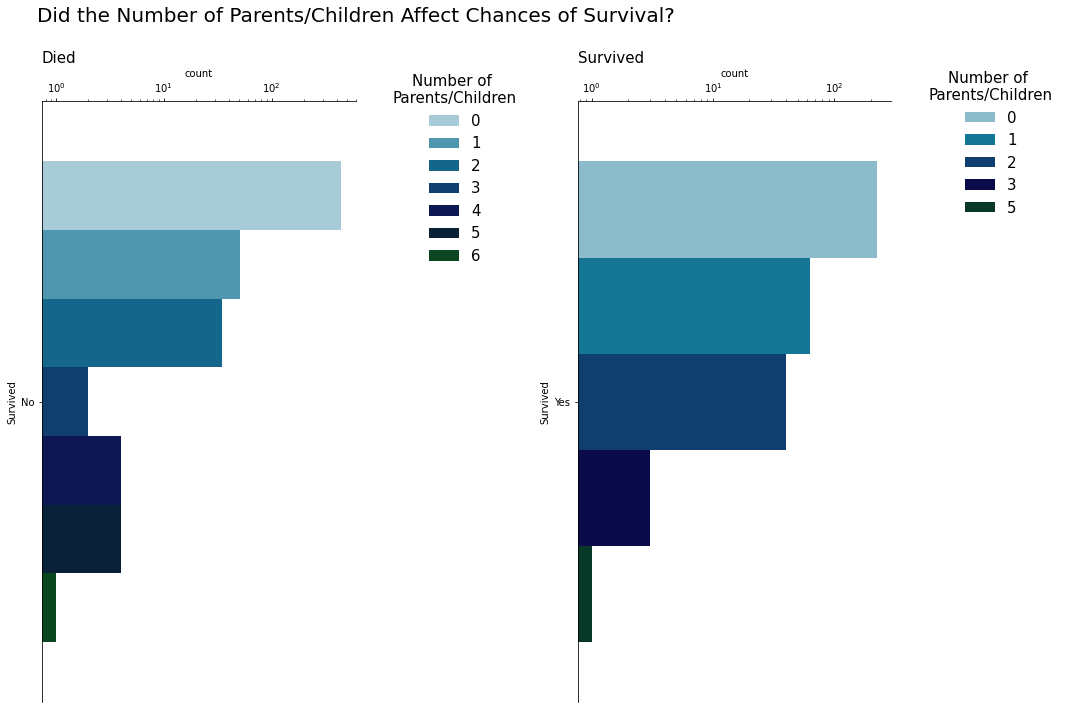

In [36]:
#Create subplots
fig, ax = plt.subplots(1,2, sharey=False)
fig.set_size_inches(15, 10)
fig.subplots_adjust(hspace=.5)

order1 = pd.crosstab(X_train.Survived[X_train.Survived == 'No'], X_train.Parch).sort_values('Survived', ascending=False).index
order2 = pd.crosstab(X_train.Survived[X_train.Survived == 'Yes'], X_train.Parch).sort_values('Survived', ascending=False).index

ax1 = sns.countplot(y ='Survived', orient = 'h', data = X_train[X_train.Survived == 'No'], hue = 'Parch', palette = 'ocean_r', order = order1, ax = ax[0])
ax2 = sns.countplot(y ='Survived', orient = 'h', data = X_train[X_train.Survived == 'Yes'], hue = 'Parch', palette = 'ocean_r', order = order2, ax = ax[1])

ax1.set(xscale="log");
ax2.set(xscale="log");

ax2.legend(title = '    Number of \nParents/Children', frameon = False, fontsize = 15, title_fontsize =15, loc=(1.1, 0.8))
# ax1.legend([],[], frameon = False)
ax1.legend(title = '    Number of \nParents/Children', frameon = False, fontsize = 15, title_fontsize =15, loc=(1.1, 0.72))

ax[0].set_title("\nDied", loc = 'left', size = 15)
ax[1].set_title("\nSurvived", loc = 'left', size = 15)

fig.suptitle("Did the Number of Parents/Children Affect Chances of Survival?", x = 0.333,size = 20)
sns.despine(top = False, bottom = True)

ax1.xaxis.set_ticks_position("top")
ax1.xaxis.set_label_position('top')

ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position('top')

fig.tight_layout()

From the barplot above:

* No one with 4 or 6 parents/children survived.

## ***Multivariate Data Analysis***

***Age, Sex & Survival***

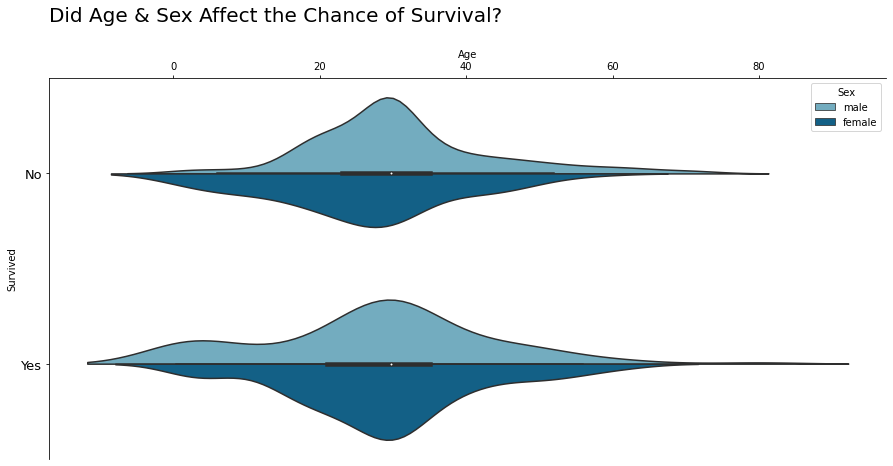

In [37]:
plt.title("Did Age & Sex Affect the Chance of Survival?\n", size =20, loc = 'left')

ax = sns.violinplot(x = 'Age', y = 'Survived', hue = 'Sex', data = X_train, orient = 'h', split = True, palette = mypal);

sns.despine(top = False, bottom = True)
plt.yticks(rotation=0, size = 13)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position('top')

From the violinplot above:

* The median age for male and female survivors and non survivors was similar.
* The distribution of female survivors was larger than male surviors.
* While sex can be an attribute to predict survival, however age is not.

***Sex, SibSp & Survival***

/opt/conda/lib/python3.7/site-packages/seaborn/axisgrid.py:670: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.


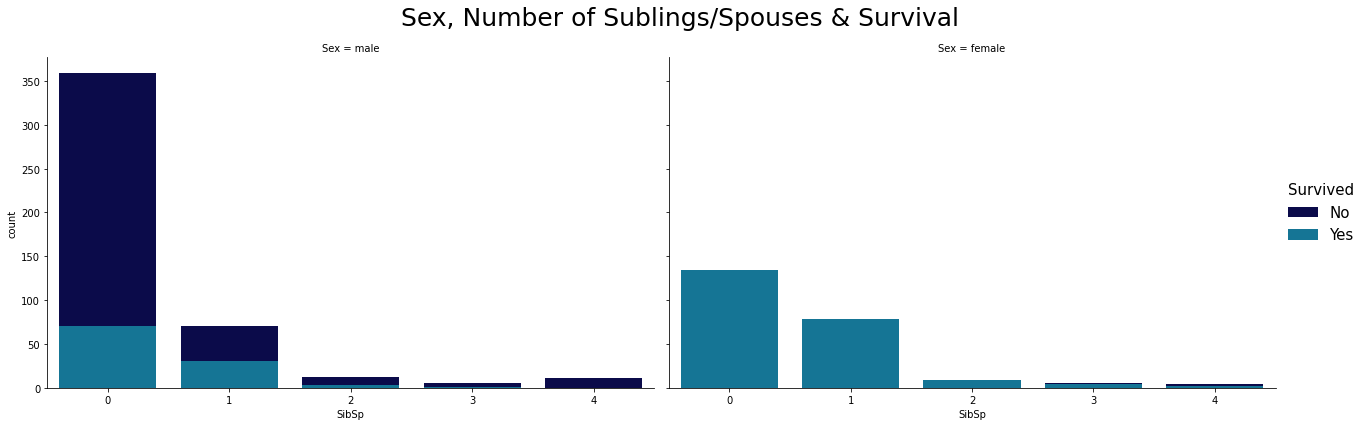

In [38]:
def countplot(x, **kwargs):
    sns.countplot(x=x, **kwargs)

g = sns.FacetGrid(X_train, col="Sex", hue = 'Survived', height = 6, aspect = 1.5, palette = 'ocean');
g.fig.suptitle("Sex, Number of Sublings/Spouses & Survival",size = 25);
g.map(sns.countplot, "SibSp");
plt.rcParams['font.size'] = 15
g.add_legend();

From the stacker barplot above:

* The number of males without siblings/spouses who didn't survive was higher than the number of males without siblings/spouses who did.
* It can be seen that the higher the number of siblings/spouses for men, the less they survived.
* Females mostly survived with or without siblings/spouses, however similar to males, some females with 3 or 4 sibsp didn't survive.

***Sex, Ticket Fare & Survival***

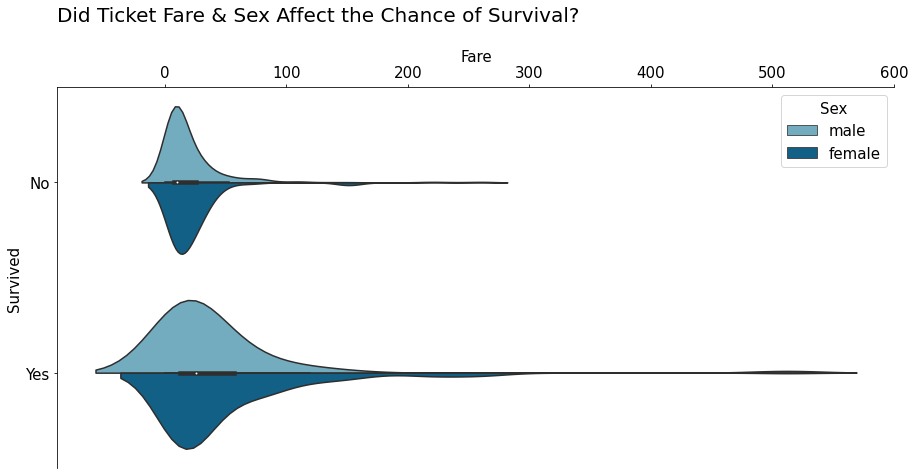

In [39]:
plt.title("Did Ticket Fare & Sex Affect the Chance of Survival?\n", size =20, loc = 'left')

ax = sns.violinplot(x = 'Fare', y = 'Survived', hue = 'Sex', data = X_train, orient = 'h', split = True, palette = mypal);

sns.despine(top = False, bottom = True)
plt.yticks(rotation=0, size = 15)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position('top')

From the violinplot above:

* As figured from previous graphs, people who paid higher fare tended to survive more.
* The distribution of females survived is a bit skewed, with higher variance.

***Ticket Fare, Pclass & Survival***

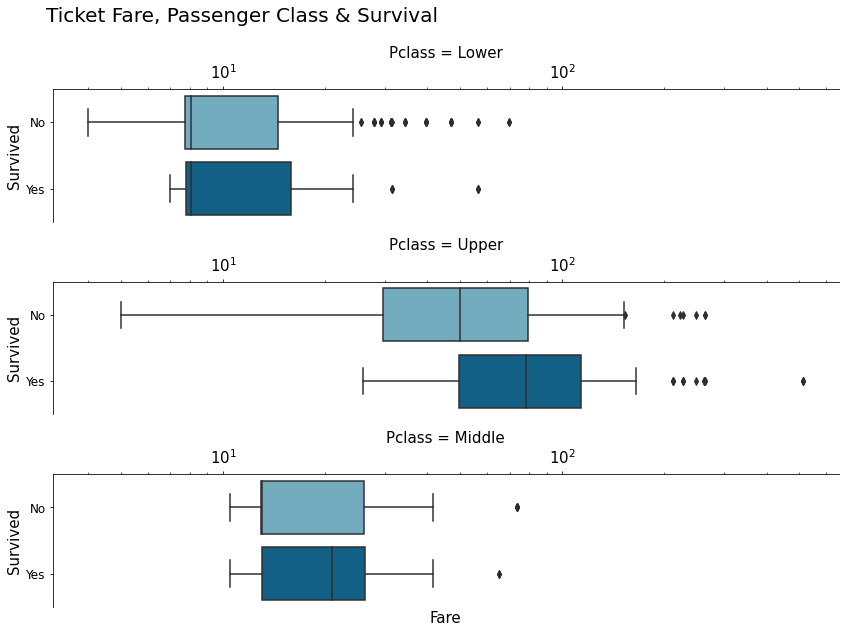

In [40]:
g = sns.catplot(x="Fare", y="Survived", row="Pclass",
                kind="box", orient="h", height = 3, aspect = 4,
                data=X_train.query("Fare > 0"), palette = mypal, sharex = True);

g.fig.suptitle("Ticket Fare, Passenger Class & Survival", x = 0.29, size = 20);

sns.despine(top = False, bottom = True)
g.set_yticklabels(rotation=0, size = 12)
g.set(xscale="log");
g.tight_layout()

From the boxplots above:

* People from lower class had similar median fare paid, however there's higher fare variance among who those who didn't survive.
* For middle class, the median fare is vastly different, those who didn't survive paid the lowest, while on average those who survived paid higher.
* For upper class, the ranges of fares paid differed as well,those who didn't survive paid lower fares on average, however among who survived they paid higher on average.